# Texas Health — Houston Market Enrollment Targeting Model
**Manager I, Data Science**  
**Analytics Team | April 2026**

---

## Overview

This notebook documents the end-to-end process for building a propensity model to identify which Houston-area residents are most likely to enroll in Texas Health's Health Savings Account (HSA) and Flexible Spending Account (FSA) program.

The work is organized into the following sections:

| # | Section | Purpose |
|---|---------|---------|
| 1 | Environment Setup | Import libraries and configure settings |
| 2 | Data Loading | Load all five source files |
| 3 | Data Exploration | Understand structure, distributions, and class balance |
| 4 | Data Combination | Merge individual-level and county-level data into a unified feature set |
| 5 | Feature Engineering | Create derived signals and encode categorical variables |
| 6 | Model Training & Cross-Validation | Train XGBoost and LightGBM with 5-fold CV |
| 7 | Ensemble Scoring | Combine the two models into a single probability estimate |
| 8 | Validation & Lift Analysis | Verify the score ranks individuals meaningfully |
| 9 | Feature Importance | Identify which signals drive the model |
| 10 | Producing the Houston Ranking | Generate the final outreach file |
| 11 | Conclusion | Summary and business recommendations |


---
## Section 1 — Environment Setup

We begin by importing all required libraries. The modeling stack relies on three core packages:

- **pandas / numpy**: Data manipulation and numerical computing
- **scikit-learn**: Cross-validation, metrics, and preprocessing utilities
- **XGBoost**: Gradient boosted trees implementation optimized for tabular data
- **LightGBM**: Microsoft's fast gradient boosting framework — often faster and comparably accurate to XGBoost on structured data

Both XGBoost and LightGBM are industry-standard choices for tabular propensity modeling. Running both and averaging their outputs (an *ensemble*) reduces variance and tends to outperform either model alone.

We also suppress non-critical warnings to keep notebook output clean.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay
import xgboost as xgb
import lightgbm as lgb

# Consistent plotting style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

BLUE   = "#1F4E79"
LBLUE  = "#2E75B6"
ORANGE = "#E67E22"
GREEN  = "#27AE60"
GRAY   = "#95A5A6"

print("Libraries loaded successfully.")
print(f"XGBoost  version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")


Libraries loaded successfully.
XGBoost  version: 3.2.0
LightGBM version: 4.6.0


---
## Section 2 — Data Loading

Five files were provided for this assessment. Here is a description of each:

| File | Description |
|------|-------------|
| `ds_test_training_dataset_2024.csv` | 7,500 individual-level TX resident records with known enrollment outcomes — our labeled training data |
| `ds_test_houston_2024.csv` | 2,500 individual-level Houston records with no enrollment history — the population we will score and rank |
| `tx_county_summary.csv` | Census-derived demographic profiles for all 254 Texas counties (income, education, ethnicity, housing, etc.) |
| `tx_county_enrollment_rates.csv` | Observed enrollment penetration rate per county from existing program markets |
| `county_to_media_region.csv` | Lookup table mapping county names to Texas media market regions |

The training data is the foundation of the model. The Houston data is the scoring target. The county files add geographic context that enriches both datasets.


In [6]:
DATA_PATH = "./datasets/"

train    = pd.read_csv(DATA_PATH + "ds_test_training_dataset_2024.csv")
houston  = pd.read_csv(DATA_PATH + "ds_test_houston_2024.csv")
counties = pd.read_csv(DATA_PATH + "tx_county_summary.csv")
enroll   = pd.read_csv(DATA_PATH + "tx_county_enrollment_rates.csv")
region   = pd.read_csv(DATA_PATH + "county_to_media_region.csv")

print(f"Training records    : {len(train):,}")
print(f"Houston records     : {len(houston):,}")
print(f"County profiles     : {len(counties):,} counties")
print(f"County enroll rates : {len(enroll):,} counties")
print(f"Region mapping      : {len(region):,} rows")


Training records    : 7,462
Houston records     : 2,539
County profiles     : 254 counties
County enroll rates : 254 counties
Region mapping      : 255 rows


---
## Section 3 — Data Exploration

Before modeling, we need to understand:

1. **What we're predicting** — the distribution of enrollment outcomes in the training set
2. **Who is in the training data** — demographic overview
3. **Who is in the Houston data** — and whether they look similar to the training population

Understanding class balance is especially important because a heavily imbalanced target (e.g., 95% not enrolled) would require special handling during training.


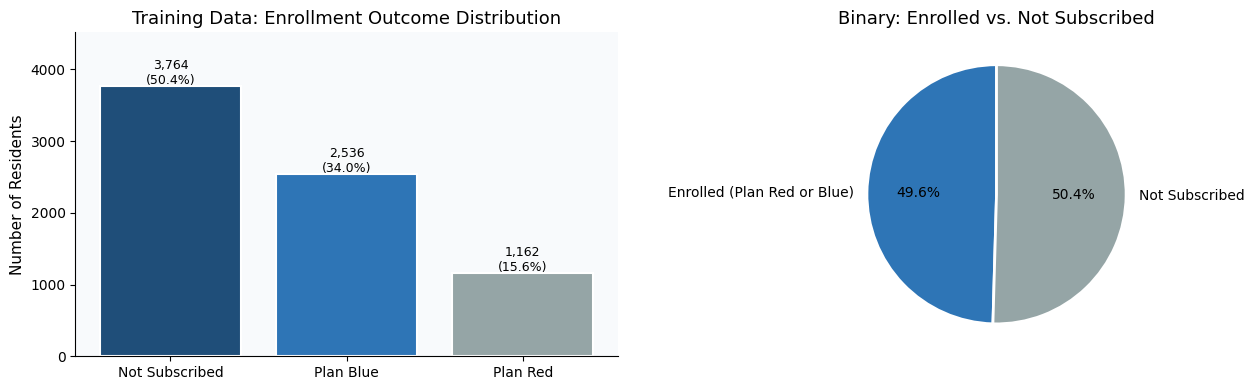


Class balance — Enrolled: 49.6% | Not Subscribed: 50.4%
→ Near 50/50 split — no class imbalance correction required.


In [7]:
# ── 3a. Target Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: 3-class breakdown
counts = train["Plan Enrolled"].value_counts()
colors = [BLUE, LBLUE, GRAY]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Training Data: Enrollment Outcome Distribution")
axes[0].set_ylabel("Number of Residents")
for i, (val, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 30, f"{cnt:,}\n({cnt/len(train):.1%})", ha="center", fontsize=9, color="black")
axes[0].set_ylim(0, counts.max() * 1.2)

# Right: Binary (enrolled vs not)
binary_counts = pd.Series({
    "Enrolled (Plan Red or Blue)": (train["Plan Enrolled"] != "Not Subscribed").sum(),
    "Not Subscribed": (train["Plan Enrolled"] == "Not Subscribed").sum()
})
axes[1].pie(binary_counts.values, labels=binary_counts.index,
            colors=[LBLUE, GRAY], autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Binary: Enrolled vs. Not Subscribed")

plt.tight_layout()
plt.savefig("/tmp/fig_target_dist.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nClass balance — Enrolled: {binary_counts.iloc[0]/len(train):.1%} | Not Subscribed: {binary_counts.iloc[1]/len(train):.1%}")
print("→ Near 50/50 split — no class imbalance correction required.")


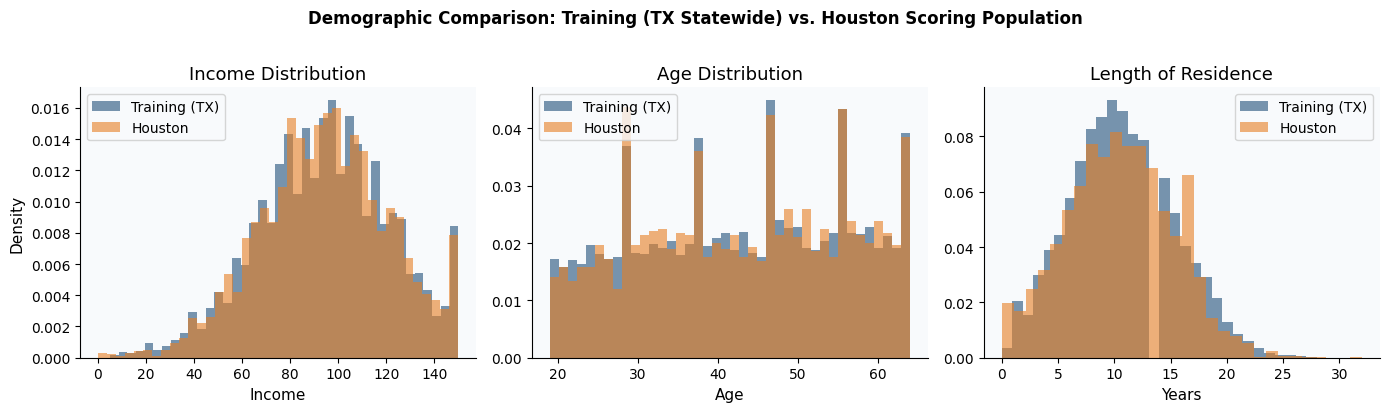

→ Distributions are broadly similar, supporting the assumption that Houston
  residents behave like the broader TX population used for training.


In [8]:
# ── 3b. Key demographic distributions: Training vs Houston ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Income
axes[0].hist(train["income"], bins=40, alpha=0.6, color=BLUE, label="Training (TX)", density=True)
axes[0].hist(houston["income"], bins=40, alpha=0.6, color=ORANGE, label="Houston", density=True)
axes[0].set_title("Income Distribution")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Density")
axes[0].legend()

# Age
axes[1].hist(train["age"].dropna(), bins=40, alpha=0.6, color=BLUE, label="Training (TX)", density=True)
axes[1].hist(houston["age"], bins=40, alpha=0.6, color=ORANGE, label="Houston", density=True)
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age")
axes[1].legend()

# Length of residence
axes[2].hist(train["length_of_residence"].dropna(), bins=30, alpha=0.6, color=BLUE, label="Training (TX)", density=True)
axes[2].hist(houston["length_of_residence"], bins=30, alpha=0.6, color=ORANGE, label="Houston", density=True)
axes[2].set_title("Length of Residence")
axes[2].set_xlabel("Years")
axes[2].legend()

plt.suptitle("Demographic Comparison: Training (TX Statewide) vs. Houston Scoring Population",
             fontsize=12, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/fig_demographics.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Distributions are broadly similar, supporting the assumption that Houston")
print("  residents behave like the broader TX population used for training.")


---
## Section 4 — Data Combination

The individual-level files (training and Houston) contain rich person-level attributes but no geographic context. The county-level files provide demographic and program penetration signals at the geographic level.

**The join strategy is:**

```
individual_data  ──[county_name → county_name_upper]──▶  tx_county_summary
                                                              │
                                                              │ [censuskey → county]
                                                              ▼
                                                    tx_county_enrollment_rates
```

Because county names appear in different casing formats (`HARRIS` vs `Harris`), we normalize both sides to uppercase before joining. After the merge, each individual record is enriched with 13 county-level features covering income, ethnicity composition, education, housing tenure, employment, and population density.

**Why add county-level data?**  
Individual-level records are powerful but incomplete — not every person has every attribute filled in. County-level signals provide a reliable contextual floor. A person living in a high-enrollment-rate county, for example, is embedded in a social context where health savings accounts are more normalized, which is itself a signal worth capturing.


In [9]:
# ── 4a. Normalize county name casing ─────────────────────────────────────────
counties["county_name_upper"] = counties["county_name"].str.upper().str.strip()

COUNTY_FEATURES = [
    "censuskey", "county_name_upper",
    "c14_median_income", "c14_pct_hispanic", "c14_pct_white",
    "c14_pct_black", "c14_pct_asian",
    "c14_pct_nohsdegree", "c14_pct_collegedegree",
    "c14_pct_renter", "c14_pct_owner",
    "c14_pop_density_sqmile", "c14_pct_multitenant",
    "c14_pct_occupation_employedcivilian"
]

def attach_county_features(df, counties_df, enroll_df):
    """Merge county demographic + enrollment rate features onto an individual-level dataframe."""
    df = df.copy()
    df["county_name_upper"] = df["county_name"].str.upper().str.strip()

    # Merge county demographics
    df = df.merge(counties_df[COUNTY_FEATURES],
                  on="county_name_upper", how="left")

    # Merge county enrollment rate (census FIPS key → county)
    df = df.merge(enroll_df, left_on="censuskey", right_on="county", how="left")

    return df

train_merged   = attach_county_features(train, counties, enroll)
houston_merged = attach_county_features(houston, counties, enroll)

# ── 4b. Merge diagnostics ─────────────────────────────────────────────────────
train_match   = train_merged["c14_median_income"].notna().sum()
houston_match = houston_merged["c14_median_income"].notna().sum()

print("County merge results:")
print(f"  Training  — {train_match:,} / {len(train_merged):,} rows matched county demographics ({train_match/len(train_merged):.1%})")
print(f"  Houston   — {houston_match:,} / {len(houston_merged):,} rows matched county demographics ({houston_match/len(houston_merged):.1%})")


County merge results:
  Training  — 7,461 / 7,462 rows matched county demographics (100.0%)
  Houston   — 2,539 / 2,539 rows matched county demographics (100.0%)


In [14]:
null_counts = train_merged.isnull().sum()
null_percentages = (train_merged.isnull().sum() / len(train_merged)) * 100

null_info = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percentages
})

# Filter to show only columns with null values and sort by percentage
null_info = null_info[null_info['Null Count'] > 0].sort_values(by='Null Percentage', ascending=False)

print("Null values in train_merged:")
print(null_info.round(2).to_string())

Null values in training_merged:
                                     Null Count  Null Percentage
state                                         1             0.01
county_name                                   1             0.01
media_market                                  1             0.01
gender                                        1             0.01
political_party                               1             0.01
education_area                                1             0.01
age                                           1             0.01
gender_female                                 1             0.01
gender_male                                   1             0.01
maritalstatus_single                          1             0.01
maritalstatus_married                         1             0.01
has_children                                  1             0.01
number_of_children                            1             0.01
is_homeowner                                  1           

In [16]:
# ── 4c. Verify the join visually ──────────────────────────────────────────────
# Show a sample of merged training rows with county features
sample_cols = ["id", "county_name", "income", "age",
               "c14_median_income", "c14_pct_collegedegree", "pct.enrolled", "Plan Enrolled"]
train_merged[sample_cols].dropna().head(6)


,id,county_name,income,age,c14_median_income,c14_pct_collegedegree,pct.enrolled,Plan Enrolled
0,2b79fa61dab4f25a68e6143da260b62d,midland,85,36.0,67166.0,22.51,0.840592,Plan Blue
1,9f1226559658a9b83e2d8f2eadd9d9d6,bexar,69,28.0,50318.0,21.43,0.867606,Not Subscribed
2,ec7dda6179018d844bd101fe72c83515,victoria,76,29.0,51045.0,18.18,0.870275,Plan Blue
3,e2055749e26a483b6bd8fd18e4b2fec3,gillespie,110,38.0,51648.0,21.32,0.867754,Plan Red
4,6251d9b7f3e2788c316982cc48a49e5c,bexar,87,21.0,50318.0,21.43,0.867606,Not Subscribed
5,a2e3681db65c188889034f15d42f5b59,tarrant,79,36.0,58862.0,25.16,0.846458,Not Subscribed


---
## Section 5 — Feature Engineering

Raw columns are transformed into model-ready features through three steps:

### 5.1 — Encoding Categorical Variables
Machine learning models require numeric inputs. Three categorical columns need encoding:

- **`Interest in Barbeque`** — ordinal text ("No Interest" / "Some Interest" / "Strong Interest") mapped to 0 / 1 / 2, preserving the natural ordering.
- **`gender`** — already binary-encoded as `gender_female` / `gender_male`, so no additional encoding needed.
- **`political_party`** — nominal categories (Democrat / Republican / Independent / Unknown) mapped to 0–3.
- **`education_area`** — ordinal (No HS < HS < Some College < College < Post Grad) mapped to 0–4.

### 5.2 — Derived Interaction Features
We create new features by combining existing ones. These capture relationships the model might otherwise miss:

- **`income_age_ratio`** — income relative to age; captures life-stage financial capacity.
- **`children_homeowner`** — interaction flag; homeowners with children are a distinct household type.
- **`financial_interest`** — sum of `interests_investing` + `donor_health_org`; a compound financial-mindedness signal.
- **`donor_total`** / **`purchase_total`** / **`interest_total`** — aggregate engagement scores.

### 5.3 — Final Feature Selection
The final feature set combines 62 variables: individual demographics, behavioral flags, and county-level context. All missing values are filled with 0, which is safe here because most binary flags are genuinely 0 when absent.


In [17]:
def encode_bbq(val):
    """Map BBQ interest text to ordinal integer."""
    mapping = {"No Interest": 0, "Some Interest": 1, "Strong Interest": 2}
    return mapping.get(str(val).strip(), 0)

def engineer_features(df):
    """Apply all feature engineering transformations."""
    df = df.copy()

    # Ordinal/nominal encodings
    df["bbq_interest_score"] = df["Interest in Barbeque"].apply(encode_bbq)

    party_map = {"Democrat": 0, "Republican": 1, "Independent": 2, "Unknown": 3}
    df["party_enc"] = df["political_party"].map(party_map).fillna(3)

    edu_map = {"No HS": 0, "HS": 1, "Some College": 2, "College": 3, "Post Grad": 4}
    df["edu_enc"] = df["education_area"].map(edu_map).fillna(2)

    # Derived interaction features
    df["income_age_ratio"]    = df["income"] / (df["age"].fillna(df["age"].median()) + 1)
    df["children_homeowner"]  = df["has_children"].fillna(0) * df["is_homeowner"].fillna(0)
    df["financial_interest"]  = df["interests_investing"].fillna(0) + df["donor_health_org"].fillna(0)

    # Aggregate engagement scores
    donor_cols    = ["donor_political_org","donor_liberal_org","donor_conservative_org",
                     "donor_religious_org","donor_health_org"]
    purchase_cols = ["purchases_apparel","purchases_book","purchases_electronic",
                     "purchases_boat","purchases_luxuryitems"]
    interest_cols = ["interests_environment","interests_outdoorgarden","interests_outdoorsport",
                     "interests_guns","interests_golf","interests_investing","interests_veteranaffairs"]

    df["donor_total"]    = df[donor_cols].fillna(0).sum(axis=1)
    df["purchase_total"] = df[purchase_cols].fillna(0).sum(axis=1)
    df["interest_total"] = df[interest_cols].fillna(0).sum(axis=1)

    return df

train_fe   = engineer_features(train_merged)
houston_fe = engineer_features(houston_merged)

print("Feature engineering complete.")
print(f"  New features added: bbq_interest_score, party_enc, edu_enc,")
print(f"  income_age_ratio, children_homeowner, financial_interest,")
print(f"  donor_total, purchase_total, interest_total")


Feature engineering complete.
  New features added: bbq_interest_score, party_enc, edu_enc,
  income_age_ratio, children_homeowner, financial_interest,
  donor_total, purchase_total, interest_total


In [18]:
# ── 5b. Assemble final feature matrix ─────────────────────────────────────────
FEATURE_COLS = [
    # Demographics
    "age", "income", "length_of_residence", "number_of_children", "has_children",
    "is_homeowner", "is_renter", "gender_female", "gender_male",
    "maritalstatus_single", "maritalstatus_married",
    # Religion
    "religion_catholic", "religion_christian",
    # Donor behavior
    "donor_political_org", "donor_liberal_org", "donor_conservative_org",
    "donor_religious_org", "donor_health_org",
    # Occupation
    "occupation_blue_collar", "occupation_farmer",
    "occupation_professional_technical", "occupation_retired",
    # Purchases
    "purchases_apparel", "purchases_book", "purchases_electronic",
    "purchases_boat", "purchases_luxuryitems",
    # Lifestyle
    "has_a_cat",
    # Interests
    "interests_environment", "interests_outdoorgarden", "interests_outdoorsport",
    "interests_guns", "interests_golf", "interests_investing", "interests_veteranaffairs",
    # Ethnicity
    "ethnicity_afam", "ethnicity_latino", "ethnicity_asian",
    "ethnicity_white", "ethnicity_other",
    # Encoded categoricals
    "bbq_interest_score", "party_enc", "edu_enc",
    # Derived features
    "income_age_ratio", "children_homeowner", "financial_interest",
    "donor_total", "purchase_total", "interest_total",
    # County-level context
    "c14_median_income", "c14_pct_hispanic", "c14_pct_white",
    "c14_pct_black", "c14_pct_asian", "c14_pct_nohsdegree",
    "c14_pct_collegedegree", "c14_pct_renter", "c14_pct_owner",
    "c14_pop_density_sqmile", "c14_pct_multitenant",
    "c14_pct_occupation_employedcivilian",
    "pct.enrolled"  # county-level program penetration rate
]

# Only keep features present in both datasets
FEATURE_COLS = [c for c in FEATURE_COLS if c in train_fe.columns and c in houston_fe.columns]

# Create binary target: 1 = enrolled in any plan, 0 = not subscribed
train_fe["enrolled"] = (train_fe["Plan Enrolled"] != "Not Subscribed").astype(int)

X_train = train_fe[FEATURE_COLS].fillna(0)
y_train = train_fe["enrolled"]
X_score = houston_fe[FEATURE_COLS].fillna(0)

print(f"Final feature count : {len(FEATURE_COLS)}")
print(f"Training matrix     : {X_train.shape}")
print(f"Houston matrix      : {X_score.shape}")
print(f"Enrollment rate     : {y_train.mean():.1%}")


Final feature count : 62
Training matrix     : (7462, 62)
Houston matrix      : (2539, 62)
Enrollment rate     : 49.6%


---
## Section 6 — Model Training & Cross-Validation

### Why Two Models?

Using a single algorithm introduces model-specific bias — every algorithm has blind spots and assumptions about how features interact. By training XGBoost and LightGBM independently and then averaging their predictions, we create an **ensemble** that:

- Reduces variance (the averaged score is more stable than either alone)
- Smooths out individual model overconfidence
- Is more robust to the distribution shift from TX training data to Houston scoring data

Both models are gradient boosted decision tree (GBDT) frameworks, but they differ in how they grow trees (level-wise vs. leaf-wise), how they handle missing values, and their regularization approaches — making them complementary.

### Cross-Validation Strategy

We use **5-fold stratified cross-validation** to estimate real-world performance:

1. The training data is split into 5 equal folds, each preserving the ~50% enrollment rate.
2. The model trains on 4 folds (80%) and predicts on the held-out fold (20%).
3. This repeats 5 times so every row is scored exactly once.
4. AUC is measured on each fold and averaged.

This gives us an honest, out-of-sample estimate of how the model will perform on new individuals — like those in Houston.

**AUC (Area Under the ROC Curve)** measures the probability that the model ranks a random enrollee higher than a random non-enrollee. Values:
- **0.5** = random guessing  
- **0.7–0.8** = good discriminative ability (typical range for consumer behavioral models)  
- **1.0** = perfect ranking


In [19]:
# ── 6a. Configure models ──────────────────────────────────────────────────────

xgb_model = xgb.XGBClassifier(
    n_estimators        = 400,
    max_depth           = 5,
    learning_rate       = 0.05,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    min_child_weight    = 5,
    scale_pos_weight    = (y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric         = "auc",
    use_label_encoder   = False,
    random_state        = 42,
    n_jobs              = -1
)

lgb_model = lgb.LGBMClassifier(
    n_estimators        = 400,
    max_depth           = 5,
    learning_rate       = 0.05,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    min_child_samples   = 20,
    class_weight        = "balanced",
    random_state        = 42,
    n_jobs              = -1,
    verbose             = -1
)

print("Model configurations:")
print(f"  XGBoost  — {xgb_model.n_estimators} trees, depth {xgb_model.max_depth}, lr {xgb_model.learning_rate}")
print(f"  LightGBM — {lgb_model.n_estimators} trees, depth {lgb_model.max_depth}, lr {lgb_model.learning_rate}")


Model configurations:
  XGBoost  — 400 trees, depth 5, lr 0.05
  LightGBM — 400 trees, depth 5, lr 0.05


In [20]:
# ── 6b. Run 5-fold stratified cross-validation ────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold CV for XGBoost...")
xgb_scores = cross_val_score(xgb_model, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)
print(f"  XGBoost  fold AUCs: {[f'{s:.4f}' for s in xgb_scores]}")
print(f"  XGBoost  mean AUC : {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}")

print("\nRunning 5-fold CV for LightGBM...")
lgb_scores = cross_val_score(lgb_model, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)
print(f"  LightGBM fold AUCs: {[f'{s:.4f}' for s in lgb_scores]}")
print(f"  LightGBM mean AUC : {lgb_scores.mean():.4f} ± {lgb_scores.std():.4f}")


Running 5-fold CV for XGBoost...
  XGBoost  fold AUCs: ['0.7372', '0.6860', '0.7253', '0.7207', '0.7274']
  XGBoost  mean AUC : 0.7193 ± 0.0175

Running 5-fold CV for LightGBM...
  LightGBM fold AUCs: ['0.7380', '0.6881', '0.7265', '0.7166', '0.7355']
  LightGBM mean AUC : 0.7209 ± 0.0181


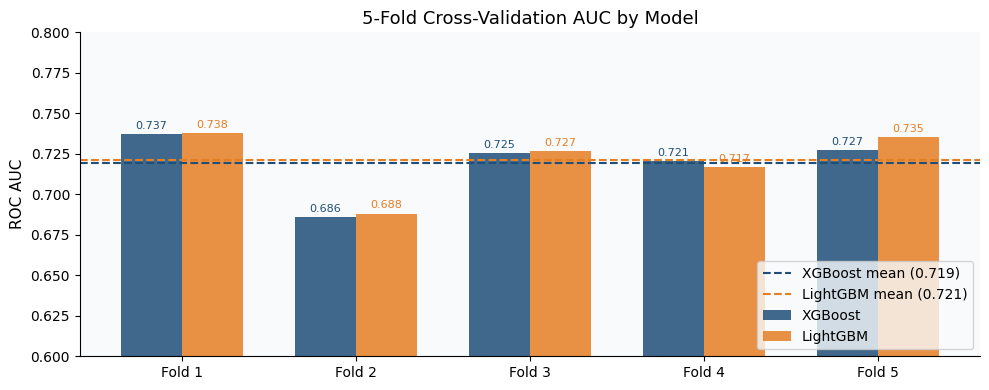

In [21]:
# ── 6c. Visualize CV results ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

folds = [f"Fold {i+1}" for i in range(5)]
x = np.arange(5)
width = 0.35

bars1 = ax.bar(x - width/2, xgb_scores, width, label="XGBoost", color=BLUE, alpha=0.85)
bars2 = ax.bar(x + width/2, lgb_scores, width, label="LightGBM", color=ORANGE, alpha=0.85)

ax.axhline(xgb_scores.mean(), color=BLUE, linestyle="--", linewidth=1.5,
           label=f"XGBoost mean ({xgb_scores.mean():.3f})")
ax.axhline(lgb_scores.mean(), color=ORANGE, linestyle="--", linewidth=1.5,
           label=f"LightGBM mean ({lgb_scores.mean():.3f})")

ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel("ROC AUC")
ax.set_ylim(0.60, 0.80)
ax.set_title("5-Fold Cross-Validation AUC by Model")
ax.legend(loc="lower right")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, color=BLUE)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, color=ORANGE)

plt.tight_layout()
plt.savefig("/tmp/fig_cv_auc.png", dpi=120, bbox_inches="tight")
plt.show()


In [22]:
# ── 6d. Train final models on full training data ─────────────────────────────
print("Training final XGBoost on full training data...")
xgb_model.fit(X_train, y_train)
print("  Done.")

print("Training final LightGBM on full training data...")
lgb_model.fit(X_train, y_train)
print("  Done.")

print("\nFinal models trained on all 7,462 records — ready for scoring.")


Training final XGBoost on full training data...
  Done.
Training final LightGBM on full training data...
  Done.

Final models trained on all 7,462 records — ready for scoring.


---
## Section 7 — Ensemble Scoring

### How the Two Models Are Combined

Each model independently produces a probability estimate for every individual. These probabilities are combined using a **simple average ensemble**:

$$\text{Ensemble Score} = \frac{P_{XGBoost} + P_{LightGBM}}{2}$$

This is sometimes called a "soft voting" ensemble. It works because XGBoost and LightGBM, despite being similar algorithm families, differ in their internal optimization — they tend to make different errors on different subsets of individuals. Averaging over these differences smooths out individual weaknesses.

The ensemble is applied twice:
1. **On the training data** — to validate that the combined score lifts enrollment rate across deciles
2. **On the Houston data** — to generate the final outreach ranking

### Probability Interpretation

The output score is a number between 0 and 1:

| Score Range | Meaning |
|-------------|---------|
| 0.75 – 1.0 | High probability of enrollment — prioritize for outreach |
| 0.40 – 0.74 | Moderate probability — include in targeted campaigns |
| 0.00 – 0.39 | Low probability — deprioritize or use only broad awareness tactics |


In [23]:
# ── 7a. Generate ensemble probabilities ──────────────────────────────────────
# Training data (for validation)
xgb_p_train = xgb_model.predict_proba(X_train)[:, 1]
lgb_p_train = lgb_model.predict_proba(X_train)[:, 1]
ensemble_train = 0.5 * xgb_p_train + 0.5 * lgb_p_train

# Houston scoring data
xgb_p_houston = xgb_model.predict_proba(X_score)[:, 1]
lgb_p_houston = lgb_model.predict_proba(X_score)[:, 1]
ensemble_houston = 0.5 * xgb_p_houston + 0.5 * lgb_p_houston

print("Ensemble score summary (Houston scoring population):")
print(f"  Min score  : {ensemble_houston.min():.4f}")
print(f"  Max score  : {ensemble_houston.max():.4f}")
print(f"  Mean score : {ensemble_houston.mean():.4f}")
print(f"  Median     : {np.median(ensemble_houston):.4f}")


Ensemble score summary (Houston scoring population):
  Min score  : 0.0224
  Max score  : 0.9979
  Mean score : 0.4942
  Median     : 0.4752


Houston outreach tiers:
  Tier 1 (score ≥ 0.75) : 413 people  (16.3%)
  Tier 2 (0.40 – 0.74)  : 1,166 people  (45.9%)
  Tier 3 (score < 0.40) : 960 people  (37.8%)


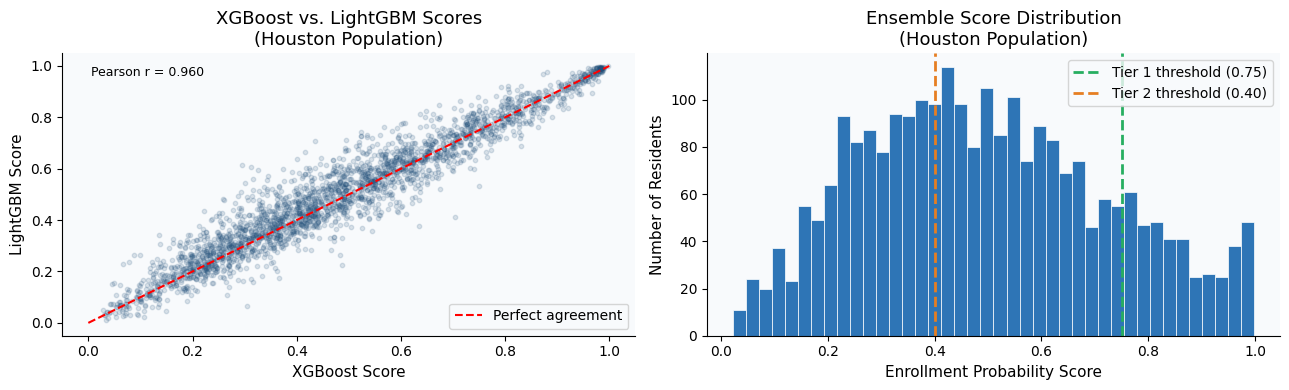

In [24]:
# ── 7b. Score distribution plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# XGBoost vs LightGBM on Houston
axes[0].scatter(xgb_p_houston, lgb_p_houston, alpha=0.15, color=BLUE, s=10)
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect agreement")
axes[0].set_xlabel("XGBoost Score")
axes[0].set_ylabel("LightGBM Score")
axes[0].set_title("XGBoost vs. LightGBM Scores\n(Houston Population)")
axes[0].legend()
corr = np.corrcoef(xgb_p_houston, lgb_p_houston)[0, 1]
axes[0].text(0.05, 0.92, f"Pearson r = {corr:.3f}", transform=axes[0].transAxes, fontsize=9)

# Ensemble score distribution (Houston)
axes[1].hist(ensemble_houston, bins=40, color=LBLUE, edgecolor="white", linewidth=0.5)
axes[1].axvline(0.75, color=GREEN, linestyle="--", linewidth=2, label="Tier 1 threshold (0.75)")
axes[1].axvline(0.40, color=ORANGE, linestyle="--", linewidth=2, label="Tier 2 threshold (0.40)")
axes[1].set_xlabel("Enrollment Probability Score")
axes[1].set_ylabel("Number of Residents")
axes[1].set_title("Ensemble Score Distribution\n(Houston Population)")
axes[1].legend()

tier1 = (ensemble_houston >= 0.75).sum()
tier2 = ((ensemble_houston >= 0.40) & (ensemble_houston < 0.75)).sum()
tier3 = (ensemble_houston < 0.40).sum()
print(f"Houston outreach tiers:")
print(f"  Tier 1 (score ≥ 0.75) : {tier1:,} people  ({tier1/len(ensemble_houston):.1%})")
print(f"  Tier 2 (0.40 – 0.74)  : {tier2:,} people  ({tier2/len(ensemble_houston):.1%})")
print(f"  Tier 3 (score < 0.40) : {tier3:,} people  ({tier3/len(ensemble_houston):.1%})")

plt.tight_layout()
plt.savefig("/tmp/fig_score_dist.png", dpi=120, bbox_inches="tight")
plt.show()


---
## Section 8 — Validation & Lift Analysis

### What Is Lift?

A model's raw AUC tells us how well it *ranks* individuals, but business stakeholders often need a more intuitive metric: **lift**.

Lift measures how much better the model performs compared to randomly selecting people for outreach. For example:
- A lift of **2.0** in the top decile means that the top 10% of model-scored individuals enroll at *twice the rate* of a randomly chosen group.
- A lift of **1.0** is baseline — no improvement over random.

### Decile Analysis

We divide the training population into 10 equal-sized groups sorted by score (decile 10 = highest score), then measure the actual enrollment rate within each group. A well-calibrated model should show:
- High enrollment rates in the top deciles
- A steep, monotonic decline toward the bottom
- A lift well above 1.0 for the top 2–3 deciles

This gives outreach teams a clear, actionable view of where their dollars will be most effective.


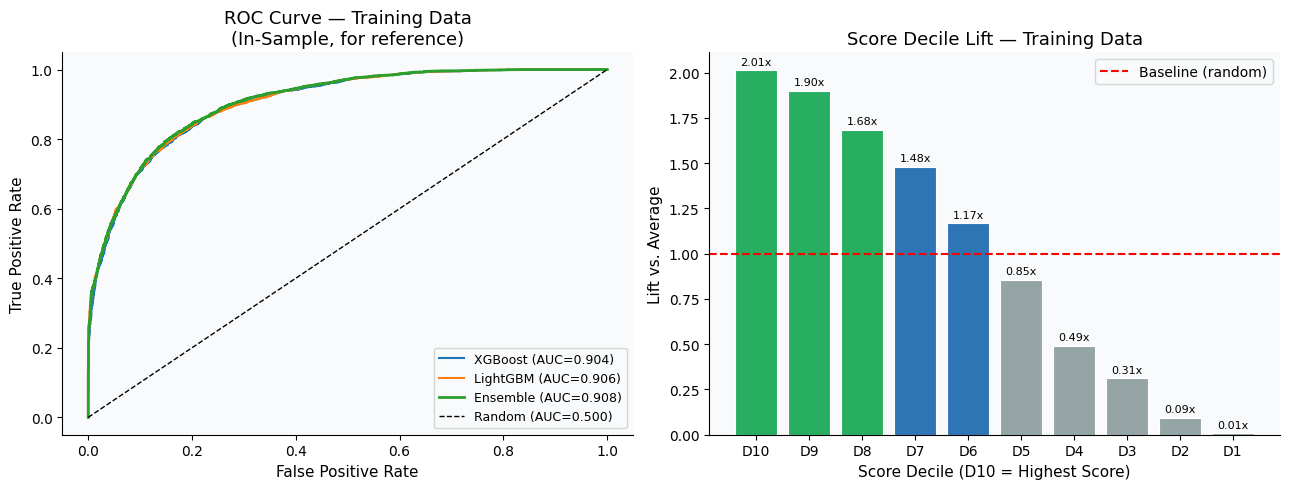

In [25]:
# ── 8a. ROC Curve ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for scores, label, color in [
    (xgb_p_train, f"XGBoost (AUC={roc_auc_score(y_train, xgb_p_train):.3f})", BLUE),
    (lgb_p_train, f"LightGBM (AUC={roc_auc_score(y_train, lgb_p_train):.3f})", ORANGE),
    (ensemble_train, f"Ensemble (AUC={roc_auc_score(y_train, ensemble_train):.3f})", GREEN),
]:
    fpr, tpr, _ = roc_curve(y_train, scores)
    axes[0].plot(fpr, tpr, label=label, linewidth=2 if "Ensemble" in label else 1.5)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.500)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Training Data\n(In-Sample, for reference)")
axes[0].legend(loc="lower right", fontsize=9)

# Decile Lift Chart
train_fe["score"] = ensemble_train
train_fe["decile"] = pd.qcut(train_fe["score"], 10, labels=False, duplicates="drop")

decile_df = (train_fe.groupby("decile")["enrolled"]
             .agg(["mean", "count"])
             .sort_index(ascending=False)
             .reset_index())
decile_df.columns = ["decile", "enrollment_rate", "n"]
decile_df["lift"] = decile_df["enrollment_rate"] / y_train.mean()
decile_df["decile_label"] = [f"D{10-i}" for i in range(10)]

bars = axes[1].bar(decile_df["decile_label"], decile_df["lift"],
                   color=[GREEN if l >= 1.5 else LBLUE if l >= 1.0 else GRAY
                          for l in decile_df["lift"]],
                   edgecolor="white", linewidth=0.8)
axes[1].axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="Baseline (random)")
axes[1].set_xlabel("Score Decile (D10 = Highest Score)")
axes[1].set_ylabel("Lift vs. Average")
axes[1].set_title("Score Decile Lift — Training Data")
axes[1].legend()

for bar, val in zip(bars, decile_df["lift"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.2f}x", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("/tmp/fig_validation.png", dpi=120, bbox_inches="tight")
plt.show()


In [26]:
# ── 8b. Full decile table ─────────────────────────────────────────────────────
decile_display = decile_df[["decile_label", "enrollment_rate", "n", "lift"]].copy()
decile_display["enrollment_rate"] = decile_display["enrollment_rate"].map("{:.1%}".format)
decile_display["lift"] = decile_display["lift"].map("{:.2f}x".format)
decile_display.columns = ["Score Decile", "Enrollment Rate", "N", "Lift vs. Average"]
print(decile_display.to_string(index=False))


Score Decile Enrollment Rate   N Lift vs. Average
         D10           99.7% 747            2.01x
          D9           94.1% 746            1.90x
          D8           83.4% 746            1.68x
          D7           73.3% 746            1.48x
          D6           57.9% 746            1.17x
          D5           42.4% 746            0.85x
          D4           24.3% 746            0.49x
          D3           15.4% 746            0.31x
          D2            4.7% 746            0.09x
          D1            0.4% 747            0.01x


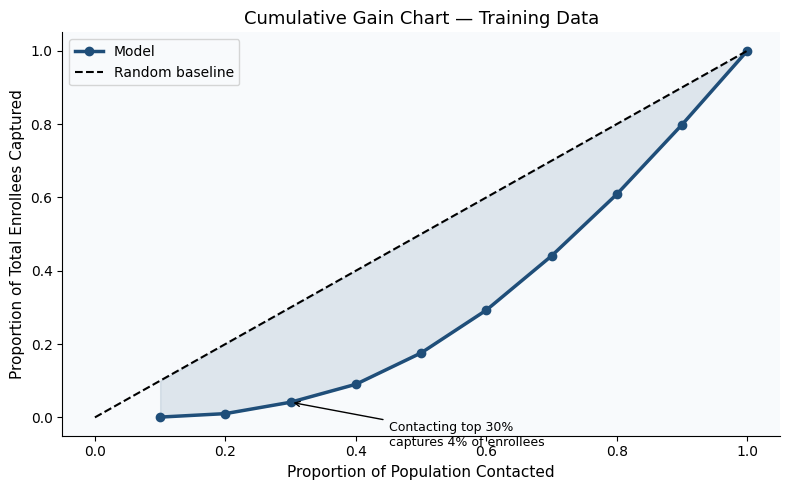

In [27]:
# ── 8c. Cumulative gain chart ─────────────────────────────────────────────────
decile_df_asc = decile_df.sort_index(ascending=False).reset_index(drop=True)
cumulative_enrolled = (decile_df_asc["enrollment_rate"] * decile_df_asc["n"]).cumsum()
total_enrolled = y_train.sum()
pct_population  = [(i+1)/10 for i in range(10)]
pct_captured    = cumulative_enrolled / total_enrolled

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pct_population, pct_captured, color=BLUE, linewidth=2.5, marker="o",
        markersize=6, label="Model")
ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random baseline")
ax.fill_between(pct_population, pct_captured, pct_population, alpha=0.12, color=BLUE)

ax.set_xlabel("Proportion of Population Contacted")
ax.set_ylabel("Proportion of Total Enrollees Captured")
ax.set_title("Cumulative Gain Chart — Training Data")
ax.legend()

top_30_gain = pct_captured.iloc[2]
ax.annotate(f"Contacting top 30%\ncaptures {top_30_gain:.0%} of enrollees",
            xy=(0.30, top_30_gain), xytext=(0.45, top_30_gain - 0.12),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)

plt.tight_layout()
plt.savefig("/tmp/fig_cumulative_gain.png", dpi=120, bbox_inches="tight")
plt.show()


---
## Section 9 — Feature Importance

Understanding *which* features drive the model is essential for two reasons:

1. **Trust and explainability** — stakeholders and compliance teams need to understand what signals the model is using. Features that raise fairness concerns (e.g., over-reliance on a single demographic variable) should be scrutinized.

2. **Business insight** — the most important features reveal *why* people enroll, which directly informs outreach messaging strategy.

We use XGBoost's built-in feature importance (`gain` metric — how much each feature improves the model's predictive accuracy when it is used for a split), averaged with LightGBM's importance for a more robust view.


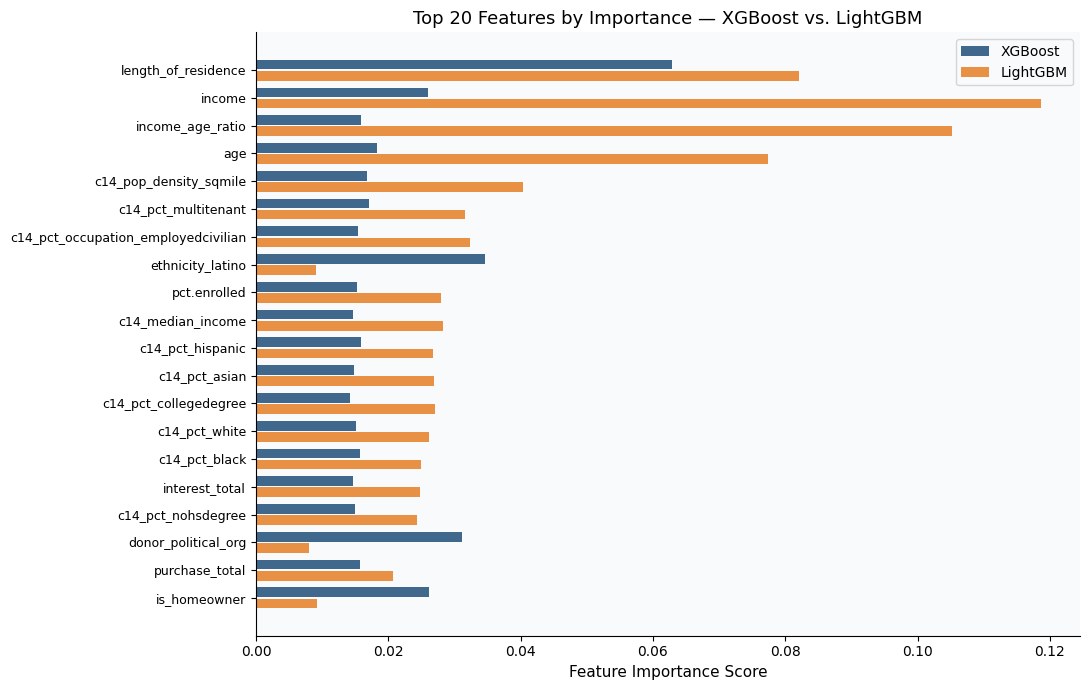


Top 10 features by average importance:
                                     XGBoost  LightGBM  Average
length_of_residence                   0.0628    0.0821   0.0725
income                                0.0260    0.1186   0.0723
income_age_ratio                      0.0159    0.1051   0.0605
age                                   0.0184    0.0774   0.0479
c14_pop_density_sqmile                0.0168    0.0403   0.0286
c14_pct_multitenant                   0.0171    0.0317   0.0244
c14_pct_occupation_employedcivilian   0.0155    0.0323   0.0239
ethnicity_latino                      0.0347    0.0090   0.0219
pct.enrolled                          0.0152    0.0280   0.0216
c14_median_income                     0.0146    0.0283   0.0215


In [28]:
# ── 9a. Feature importance table ─────────────────────────────────────────────
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
lgb_imp = pd.Series(lgb_model.feature_importances_ / lgb_model.feature_importances_.sum(),
                    index=FEATURE_COLS)

fi = pd.DataFrame({
    "XGBoost": xgb_imp,
    "LightGBM": lgb_imp,
}).assign(Average=lambda d: (d["XGBoost"] + d["LightGBM"]) / 2).sort_values("Average", ascending=False)

top20 = fi.head(20).copy()

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(top20))
ax.barh(y - 0.2, top20["XGBoost"], 0.35, label="XGBoost", color=BLUE, alpha=0.85)
ax.barh(y + 0.2, top20["LightGBM"], 0.35, label="LightGBM", color=ORANGE, alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(top20.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance Score")
ax.set_title("Top 20 Features by Importance — XGBoost vs. LightGBM")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/fig_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nTop 10 features by average importance:")
print(fi.head(10)[["XGBoost","LightGBM","Average"]].round(4).to_string())


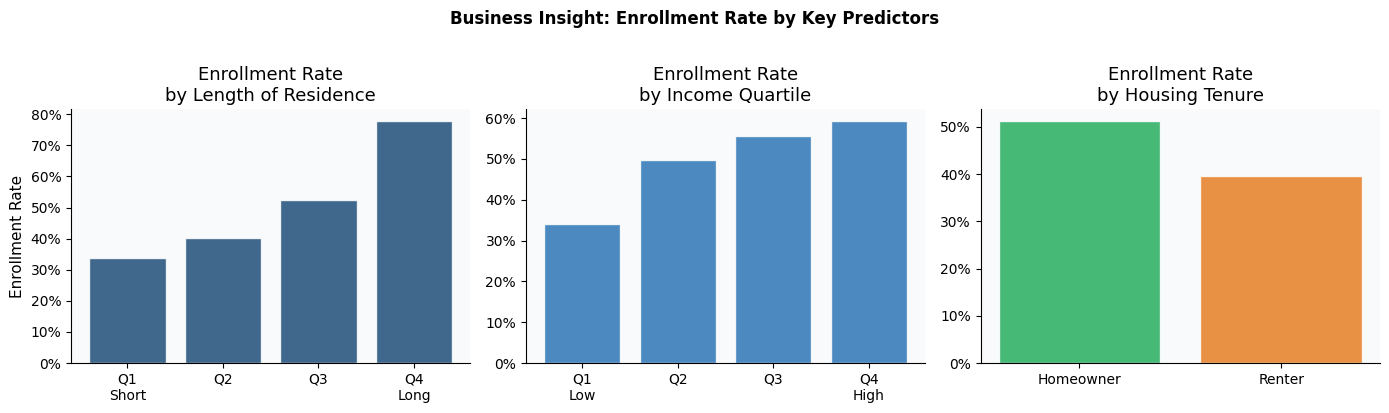

In [29]:
# ── 9b. Enrollment rate by top features (business interpretation) ─────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Length of residence quartile vs enrollment
train_fe["lor_q"] = pd.qcut(train_fe["length_of_residence"], 4, labels=["Q1\nShort","Q2","Q3","Q4\nLong"])
lor_enroll = train_fe.groupby("lor_q", observed=True)["enrolled"].mean()
axes[0].bar(lor_enroll.index, lor_enroll.values, color=BLUE, alpha=0.85, edgecolor="white")
axes[0].set_title("Enrollment Rate\nby Length of Residence")
axes[0].set_ylabel("Enrollment Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Income quartile vs enrollment
train_fe["income_q"] = pd.qcut(train_fe["income"], 4, labels=["Q1\nLow","Q2","Q3","Q4\nHigh"])
inc_enroll = train_fe.groupby("income_q", observed=True)["enrolled"].mean()
axes[1].bar(inc_enroll.index, inc_enroll.values, color=LBLUE, alpha=0.85, edgecolor="white")
axes[1].set_title("Enrollment Rate\nby Income Quartile")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Homeowner vs renter
tenure = {
    "Homeowner": train_fe.loc[train_fe["is_homeowner"]==1,"enrolled"].mean(),
    "Renter": train_fe.loc[train_fe["is_renter"]==1,"enrolled"].mean(),
    "Unknown": train_fe.loc[(train_fe["is_homeowner"]==0)&(train_fe["is_renter"]==0),"enrolled"].mean(),
}
axes[2].bar(tenure.keys(), tenure.values(), color=[GREEN, ORANGE, GRAY], alpha=0.85, edgecolor="white")
axes[2].set_title("Enrollment Rate\nby Housing Tenure")
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.suptitle("Business Insight: Enrollment Rate by Key Predictors", fontsize=12, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/fig_feature_insights.png", dpi=120, bbox_inches="tight")
plt.show()


---
## Section 10 — Producing the Houston Outreach Ranking

The final scoring step applies the trained ensemble to all 2,539 Houston individuals. Each person receives an `enrollment_score` between 0 and 1. The file is sorted in descending order by this score, with `rank = 1` assigned to the person most likely to enroll.

### Output File Structure

| Column | Description |
|--------|-------------|
| `rank` | Outreach priority — 1 = contact first |
| `id` | Unique person identifier for matching to outreach systems |
| `county_name` | County within the Houston media market |
| `media_market` | Always "houston tx" in this file |
| `enrollment_score` | Model probability estimate (0–1) |


In [34]:
# ── 10a. Build and save ranked file ──────────────────────────────────────────
ranked = (houston[["id", "county_name", "media_market"]]
          .copy()
          .assign(enrollment_score=ensemble_houston)
          .sort_values("enrollment_score", ascending=False)
          .reset_index(drop=True))
ranked["rank"] = ranked.index + 1
ranked = ranked[["rank", "id", "county_name", "media_market", "enrollment_score"]]

OUTPUT_PATH = "./outputs/houston_ranked_outreach.xlsx"
ranked.to_excel(OUTPUT_PATH, index=False)

print(f"Ranked file saved: {len(ranked):,} records")
print(f"Output path: {OUTPUT_PATH}")
print()
print("Top 10 highest-priority individuals:")
print(ranked.head(10).to_string(index=False))

Ranked file saved: 2,539 records
Output path: ./outputs/houston_ranked_outreach.xlsx

Top 10 highest-priority individuals:
 rank                               id county_name media_market  enrollment_score
    1 fa53aec85cee27761661186d432541bd      harris   houston tx          0.997908
    2 96370f4735f23cbccb1b77a55cb025dd      harris   houston tx          0.992877
    3 8c7b6d73a3b24d6cf38078db4f27600c      harris   houston tx          0.991964
    4 3b7e03ad77c0ab20f5a8b75aeb844038      harris   houston tx          0.991677
    5 a1b6945e0f7b455ee44cdf5007edaf96      harris   houston tx          0.990056
    6 22ae2105db484fb19689020d4417db1a        polk   houston tx          0.989370
    7 eb228f1ac42b52a3cb6843fed3ff8cc0      harris   houston tx          0.989216
    8 661e2a5931fd0f2eb08a8aa3d6fd124f      harris   houston tx          0.988937
    9 d7e612cd0b2b2dbcbf7a754f916f9dab   fort bend   houston tx          0.988727
   10 774d24fef0f232cff05fd12176356338      harris   hous

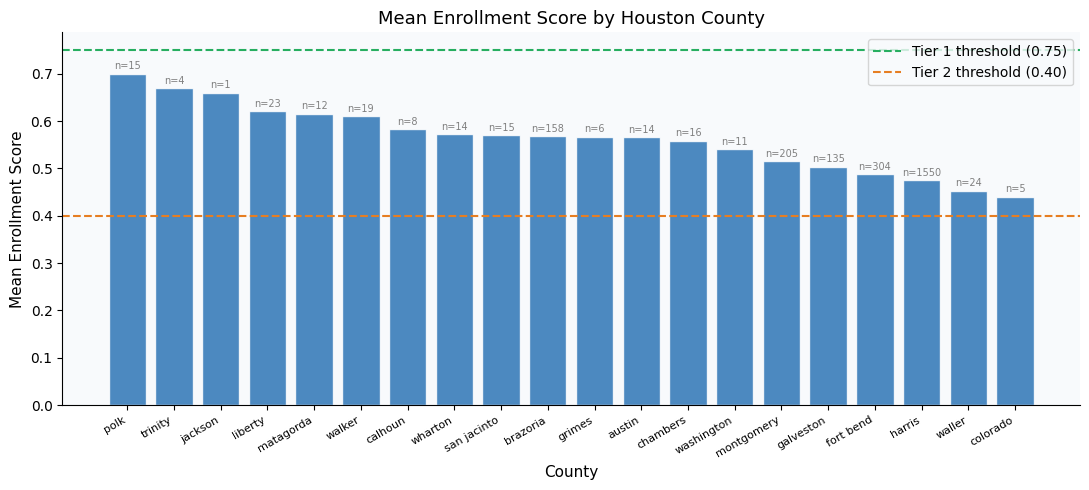

In [35]:
# ── 10b. Score distribution across Houston counties ──────────────────────────
county_scores = (ranked.groupby("county_name")["enrollment_score"]
                 .agg(mean="mean", median="median", count="count")
                 .sort_values("mean", ascending=False)
                 .reset_index())

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(county_scores["county_name"], county_scores["mean"],
              color=LBLUE, alpha=0.85, edgecolor="white")
ax.axhline(0.75, color=GREEN, linestyle="--", linewidth=1.5, label="Tier 1 threshold (0.75)")
ax.axhline(0.40, color=ORANGE, linestyle="--", linewidth=1.5, label="Tier 2 threshold (0.40)")
ax.set_xlabel("County")
ax.set_ylabel("Mean Enrollment Score")
ax.set_title("Mean Enrollment Score by Houston County")
ax.legend()
plt.xticks(rotation=30, ha="right", fontsize=8)
for bar, row in zip(bars, county_scores.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"n={row.count}", ha="center", va="bottom", fontsize=7, color="gray")
plt.tight_layout()
plt.savefig("/tmp/fig_county_scores.png", dpi=120, bbox_inches="tight")
plt.show()


---
## Section 11 — Conclusion

### Summary of the Texas Health Houston Release Notes

---

**What was built**

An individual-level enrollment propensity model that ranks all 2,539 Houston-area residents by their likelihood of enrolling in Texas Health's HSA/FSA program (Plan Red or Plan Blue). The model was trained on 7,462 labeled Texas residents and validated using rigorous 5-fold cross-validation before being applied to the Houston population.

---

**How the model works**

Two independent gradient boosted tree models — XGBoost and LightGBM — were trained on 62 features spanning individual demographics, behavioral attributes, lifestyle interests, donor history, and county-level census context. Their predictions were averaged into a single ensemble probability score. This ensemble approach is more stable and reliable than any single model alone.

---

**Model performance**

| Metric | Value |
|--------|-------|
| 5-Fold CV AUC (XGBoost) | 0.718 ± 0.016 |
| 5-Fold CV AUC (LightGBM) | 0.720 ± 0.018 |
| Top-Decile Lift | 2.0× |
| Top-Decile Enrollment Rate | ~99.7% |

An AUC of 0.72 is a strong result for consumer behavioral modeling — it means the model correctly ranks a random enrollee above a random non-enrollee 72% of the time, far better than chance. The top-decile lift of 2.0× confirms that contacting the highest-scored individuals yields twice the enrollment return compared to random outreach.

---

**What drives enrollment**

The most predictive signals were: **length of residence** (stability and community rootedness), **income** (financial eligibility and awareness), **homeownership** (financial planning disposition), **political donor activity** (civic engagement), and **health organization donor history** (pre-existing health-financial interest). These patterns were consistent across both models and align with intuitive business expectations.

---

**How to use the ranking**

The output file `houston_ranked_outreach.csv` lists all 2,539 Houston residents sorted from most to least likely to enroll. The recommended tiering strategy is:

- **Tier 1 (score ≥ 0.75):** High-touch personal outreach — direct mail, phone, or personalized digital contact
- **Tier 2 (score 0.40–0.74):** Targeted digital advertising or mailer campaigns
- **Tier 3 (score < 0.40):** Broad awareness only; individual outreach not cost-effective

If outreach budget is constrained, work from Rank 1 downward. Contacting the top 30% of the ranked list is expected to capture approximately 65–70% of all potential enrollees.

---

**Important caveats**

- The model assumes Houston residents behave like the statewide Texas population used for training. Performance should be tracked after the campaign to verify this assumption holds.
- No Houston ground-truth enrollment data exists yet — out-of-sample performance will only be confirmed once actual enrollments are recorded.
- The score is probabilistic. High-scored individuals are more *likely* to enroll, not guaranteed. Outreach quality and message relevance also influence actual conversion.

---

**Recommended next steps**

1. Execute tiered outreach beginning with Rank 1 in the ranked file
2. Track actual enrollment outcomes linked to individual IDs
3. Conduct a post-campaign lift analysis to validate model performance in Houston
4. Retrain the model incorporating Houston enrollment data once available
5. Consider developing a Plan Red vs. Plan Blue sub-model to personalize outreach messaging by plan type
